In [3]:
from netCDF4 import Dataset

#Ponerle nombre a nuestro archivo netcdf
file_in = Dataset(r"C:\Users\danna\INSTRUGEO\Viento.nc")

#Ver variables generales y atributos
for var_name in file_in.variables:
    var = file_in.variables[var_name]
    print(f"Variable: {var_name}")
    print(f"  - Dimensions: {var.dimensions}")
    print(f"  - Shape: {var.shape}")
    if hasattr(var, 'short_name'):
        print(f"  - Short name: {var.short_name}")
    if hasattr(var, 'standard_name'):
        print(f"  - Standard name: {var.standard_name}")
    if hasattr(var, 'long_name'):
        print(f"  - Long name: {var.long_name}")
    if hasattr(var, 'units'):
        print(f"  - Units: {var.units}")
    print()

Variable: number
  - Dimensions: ()
  - Shape: ()
  - Standard name: realization
  - Long name: ensemble member numerical id
  - Units: 1

Variable: valid_time
  - Dimensions: ('valid_time',)
  - Shape: (7671,)
  - Standard name: time
  - Long name: time
  - Units: seconds since 1970-01-01

Variable: latitude
  - Dimensions: ('latitude',)
  - Shape: (1,)
  - Standard name: latitude
  - Long name: latitude
  - Units: degrees_north

Variable: longitude
  - Dimensions: ('longitude',)
  - Shape: (7,)
  - Standard name: longitude
  - Long name: longitude
  - Units: degrees_east

Variable: expver
  - Dimensions: ('valid_time',)
  - Shape: (7671,)

Variable: u10
  - Dimensions: ('valid_time', 'latitude', 'longitude')
  - Shape: (7671, 1, 7)
  - Standard name: unknown
  - Long name: 10 metre U wind component
  - Units: m s**-1



In [5]:
# CONVERTIR NETCDF A CSV
# EXTRAER DATOS DE VIENTO (ERA5)

import pandas as pd
import numpy as np
import os
from netCDF4 import Dataset, num2date

# Lista de archivos (en tu caso solo uno)
archivos = [
    'Viento'
]

# Lista donde se van a guardar todos los datos
all_rows = []

# Recorrer cada archivo
for archivo in archivos:
    
    # Abrir archivo NetCDF desde tu ruta
    file_in = Dataset(rf"C:\Users\danna\INSTRUGEO\{archivo}.nc")

    # Extraer variables principales
    lat_data = file_in.variables['latitude'][:]
    lon_data = file_in.variables['longitude'][:]
    viento_data = file_in.variables['u10'][:]   # componente zonal del viento
    time_data = file_in.variables['valid_time'][:]

    # Convertir tiempo a formato fecha
    t_unit = file_in.variables['valid_time'].units
    t_cal = file_in.variables['valid_time'].calendar
    time_values = num2date(time_data, units=t_unit, calendar=t_cal)

    # Pasar fechas a string para guardarlas fácil
    time_strings = [t.strftime("%Y-%m-%d %H:%M") for t in time_values]

    # Recorrer tiempo, latitud y longitud para guardar cada dato
    for t_index, time in enumerate(time_strings):
        for lat_index, lat in enumerate(lat_data):
            for lon_index, lon in enumerate(lon_data):
                
                valor = viento_data[t_index, lat_index, lon_index]
                
                # Guardar fila
                all_rows.append([time, lat, lon, valor])

# Crear DataFrame final
df_viento = pd.DataFrame(
    all_rows, 
    columns=["Date", "Latitude", "Longitude", "Viento_u10 (m/s)"]
)

# Guardar CSV en la misma carpeta donde está el script/notebook
output_path = r"C:\Users\danna\INSTRUGEO\Viento_extraido.csv"

df_viento.to_csv(output_path, index=False)

print(f"Datos exportados correctamente en: {output_path}")

Datos exportados correctamente en: C:\Users\danna\INSTRUGEO\Viento_extraido.csv


In [9]:
df_viento = pd.read_csv(r"C:\Users\danna\INSTRUGEO\Viento_extraido.csv")
df_viento.head()

,Date,Latitude,Longitude,Viento_u10 (m/s)
0,1996-01-01 06:00,2.0,-79.50,6.006088
1,1996-01-01 06:00,2.0,-79.25,5.911362
2,1996-01-01 06:00,2.0,-79.00,5.543198
3,1996-01-01 06:00,2.0,-78.75,4.718979
4,1996-01-01 06:00,2.0,-78.50,1.641830


In [10]:
import pandas as pd

# usar tu dataframe real
df = df_viento

# convertir la columna Date a formato datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# crear columna con el día del año (1–365)
df['DiaDelAnio'] = df['Date'].dt.dayofyear

# crear columna de año
df['Year'] = df['Date'].dt.year

# mostrar las primeras filas para verificar
print(df[['Date', 'Year', 'DiaDelAnio', 'Viento_u10 (m/s)']].head())

# guardar nuevo CSV con las columnas adicionales
df.to_csv(r"C:\Users\danna\INSTRUGEO\Viento_con_dia_del_anio.csv", index=False)

                 Date  Year  DiaDelAnio  Viento_u10 (m/s)
0 1996-01-01 06:00:00  1996           1          6.006088
1 1996-01-01 06:00:00  1996           1          5.911362
2 1996-01-01 06:00:00  1996           1          5.543198
3 1996-01-01 06:00:00  1996           1          4.718979
4 1996-01-01 06:00:00  1996           1          1.641830


<H3>TENDENCIA VCL 

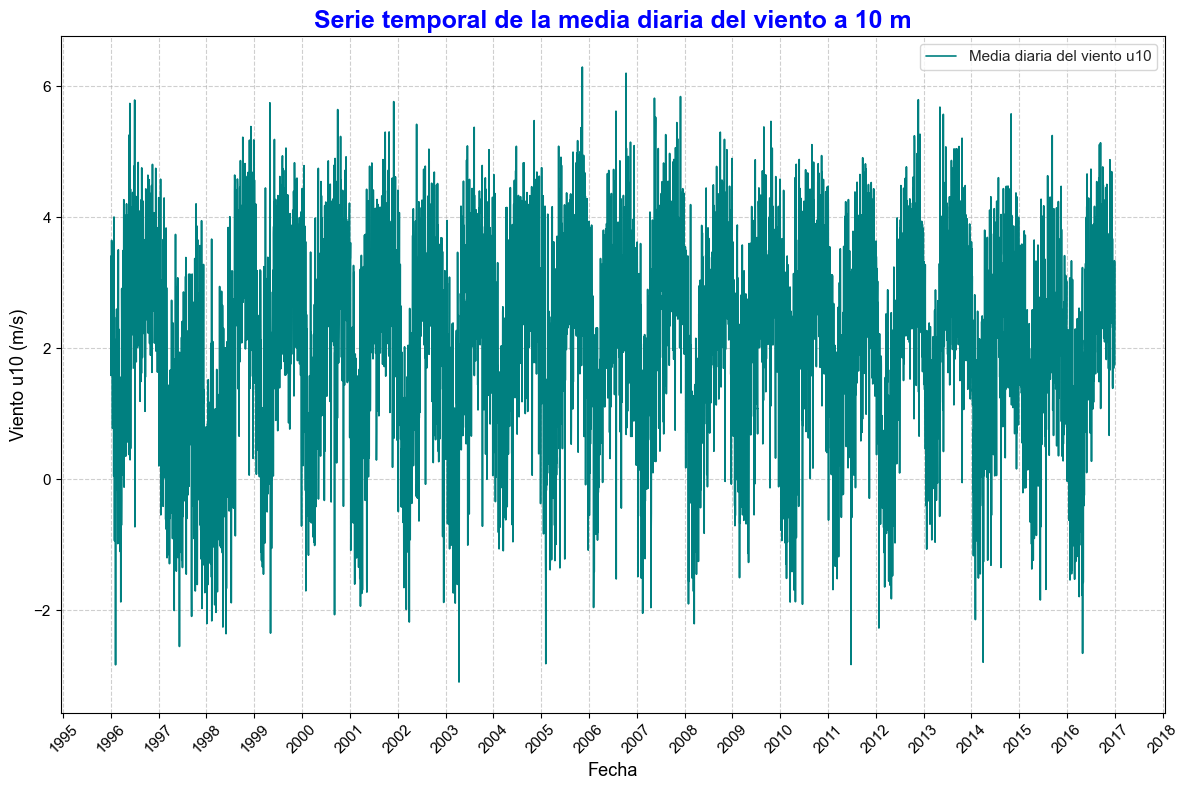

In [13]:
!pip install pymannkendall
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np
import pymannkendall as mk
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

# nombre de tu archivo real
archivo_csv = r"C:\Users\danna\INSTRUGEO\Viento_con_dia_del_anio.csv"

# variable global para guardar la media diaria
viento_media_diaria = None

def graficar_media_diaria(archivo_csv):
    try:
        global viento_media_diaria

        # leer archivo y convertir fecha
        df = pd.read_csv(archivo_csv, parse_dates=["Date"])

        # asegurar que la columna del viento sea numérica
        df["Viento_u10 (m/s)"] = pd.to_numeric(df["Viento_u10 (m/s)"], errors="coerce")

        # verificar que existan las columnas necesarias
        columnas_requeridas = {"Date", "DiaDelAnio", "Viento_u10 (m/s)"}
        if not columnas_requeridas.issubset(df.columns):
            raise ValueError(f"El archivo debe contener las columnas {columnas_requeridas}.")

        # calcular media diaria por fecha completa
        viento_media_diaria = df.groupby("Date")["Viento_u10 (m/s)"].mean().reset_index()

        # crear figura
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.set_style("whitegrid")

        # graficar serie diaria
        ax.plot(
            viento_media_diaria["Date"],
            viento_media_diaria["Viento_u10 (m/s)"],
            color="teal",
            linewidth=1.2,
            label="Media diaria del viento u10"
        )

        # formato del eje X para mostrar años
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        # título y etiquetas
        ax.set_title(
            "Serie temporal de la media diaria del viento a 10 m",
            fontsize=18,
            color="blue",
            fontweight="bold"
        )
        ax.set_xlabel("Fecha", fontsize=13)
        ax.set_ylabel("Viento u10 (m/s)", fontsize=13)

        # mejorar etiquetas
        ax.tick_params(axis='x', rotation=45, labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        # leyenda y grilla
        ax.legend(fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.6)

        plt.tight_layout()

        # guardar imagen antes de mostrar
        plt.savefig("Serie_media_diaria_viento_u10.png", dpi=300, bbox_inches="tight")

        plt.show()

    except Exception as e:
        print(f"Error: {e}")

graficar_media_diaria(archivo_csv)

Ecuación de la línea de tendencia: y = 0.000033x + 2.194335


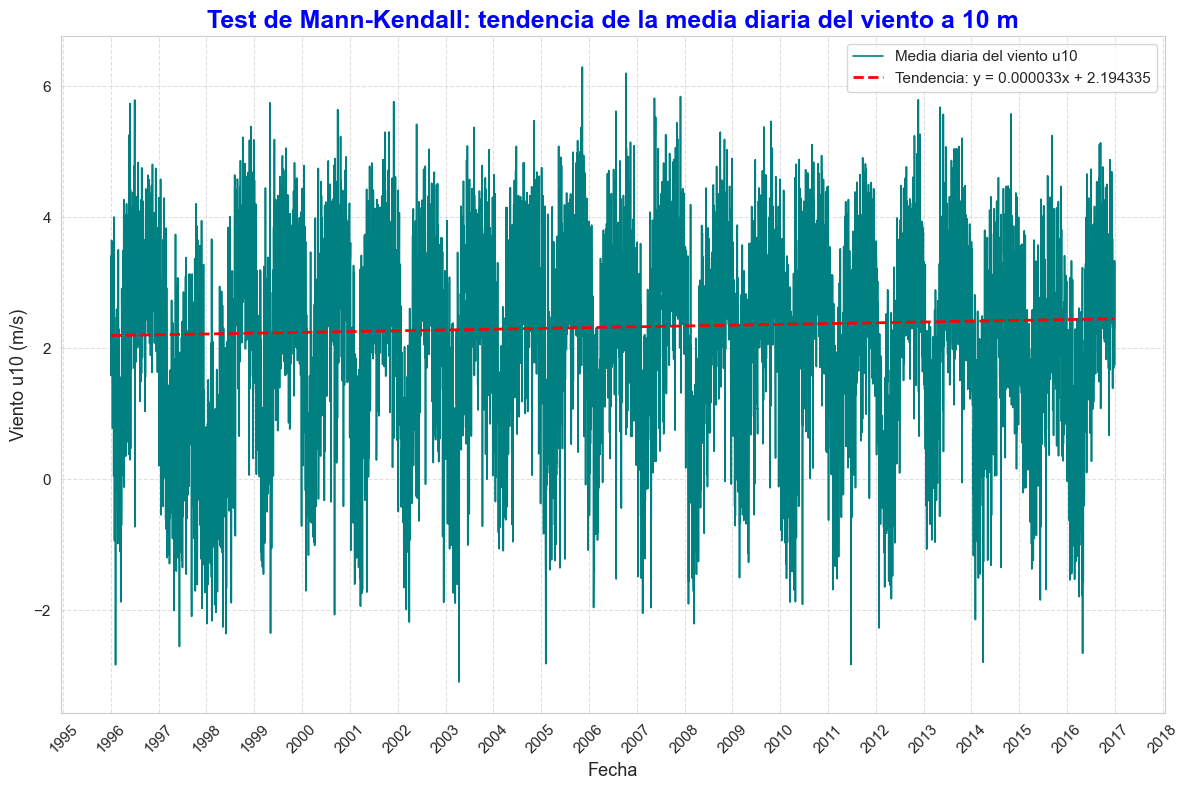

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(1.706181030947107e-05), z=np.float64(4.300233678292403), Tau=np.float64(0.03273967194212715), s=np.float64(963145.0), var_s=50164713321.666664, slope=np.float64(3.340411576644806e-05), intercept=np.float64(2.1943352246071006))


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import matplotlib.dates as mdates
import seaborn as sns

# asegurarse de que viento_media_diaria ya fue creado con la función anterior
data = viento_media_diaria["Viento_u10 (m/s)"]

# aplicar test de Mann-Kendall
res = mk.original_test(data)

# extraer pendiente e intersección de la tendencia
slope = res.slope
intercept = res.intercept

# construir línea de tendencia
trend_line = np.arange(len(data)) * slope + intercept

# imprimir ecuación de la recta
print(f"Ecuación de la línea de tendencia: y = {slope:.6f}x + {intercept:.6f}")

# estilo visual
sns.set_style("whitegrid")

# graficar serie y tendencia
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(
    viento_media_diaria["Date"],
    data,
    label="Media diaria del viento u10",
    color="teal",
    linewidth=1.2
)

ax.plot(
    viento_media_diaria["Date"],
    trend_line,
    linestyle="dashed",
    color="red",
    linewidth=2,
    label=f"Tendencia: y = {slope:.6f}x + {intercept:.6f}"
)

# formato del eje X para mostrar años
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# etiquetas y título mejorados
ax.set_ylabel("Viento u10 (m/s)", fontsize=13)
ax.set_xlabel("Fecha", fontsize=13)
ax.set_title(
    "Test de Mann-Kendall: tendencia de la media diaria del viento a 10 m",
    fontsize=18,
    color="blue",
    fontweight="bold"
)

# leyenda y grilla
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# guardar figura
plt.savefig("Tendencia_MannKendall_viento_u10.png", dpi=300, bbox_inches="tight")

plt.show()

# volver a imprimir el resultado completo del test
manni = mk.original_test(viento_media_diaria["Viento_u10 (m/s)"], alpha=0.05)
print(manni)

In [16]:
data

0       3.406060
1       1.586140
2       1.955069
3       1.742305
4       2.592124
          ...   
7666    2.281176
7667    2.986697
7668    3.338122
7669    3.275016
7670    1.755559
Name: Viento_u10 (m/s), Length: 7671, dtype: float64

<H3>TENDENCIA SWH

In [17]:
from netCDF4 import Dataset

#Ponerle nombre a nuestro archivo netcdf
file_in = Dataset(r"C:\Users\danna\INSTRUGEO\HSig.nc")

#Ver variables generales y atributos
for var_name in file_in.variables:
    var = file_in.variables[var_name]
    print(f"Variable: {var_name}")
    print(f"  - Dimensions: {var.dimensions}")
    print(f"  - Shape: {var.shape}")
    if hasattr(var, 'short_name'):
        print(f"  - Short name: {var.short_name}")
    if hasattr(var, 'standard_name'):
        print(f"  - Standard name: {var.standard_name}")
    if hasattr(var, 'long_name'):
        print(f"  - Long name: {var.long_name}")
    if hasattr(var, 'units'):
        print(f"  - Units: {var.units}")
    print()

Variable: number
  - Dimensions: ()
  - Shape: ()
  - Standard name: realization
  - Long name: ensemble member numerical id
  - Units: 1

Variable: valid_time
  - Dimensions: ('valid_time',)
  - Shape: (7671,)
  - Standard name: time
  - Long name: time
  - Units: seconds since 1970-01-01

Variable: latitude
  - Dimensions: ('latitude',)
  - Shape: (1,)
  - Standard name: latitude
  - Long name: latitude
  - Units: degrees_north

Variable: longitude
  - Dimensions: ('longitude',)
  - Shape: (4,)
  - Standard name: longitude
  - Long name: longitude
  - Units: degrees_east

Variable: expver
  - Dimensions: ('valid_time',)
  - Shape: (7671,)

Variable: swh
  - Dimensions: ('valid_time', 'latitude', 'longitude')
  - Shape: (7671, 1, 4)
  - Standard name: unknown
  - Long name: Significant height of combined wind waves and swell
  - Units: m



In [18]:
# CONVERTIR NETCDF A CSV
# EXTRAER DATOS DE ALTURA SIGNIFICANTE DE OLA (Hs) - ERA5

import pandas as pd
import numpy as np
import os
from netCDF4 import Dataset, num2date

# Lista de archivos (en este caso solo uno)
archivos = [
    'HSig'
]

# Lista donde se van a guardar todos los datos
all_rows = []

# Recorrer cada archivo
for archivo in archivos:
    
    # Abrir archivo NetCDF desde tu ruta
    file_in = Dataset(rf"C:\Users\danna\INSTRUGEO\{archivo}.nc")

    # Extraer variables principales
    lat_data = file_in.variables['latitude'][:]
    lon_data = file_in.variables['longitude'][:]
    hs_data = file_in.variables['swh'][:]   # altura significante de ola
    time_data = file_in.variables['valid_time'][:]

    # Convertir tiempo a formato fecha
    t_unit = file_in.variables['valid_time'].units
    t_cal = file_in.variables['valid_time'].calendar
    time_values = num2date(time_data, units=t_unit, calendar=t_cal)

    # Pasar fechas a string para guardarlas fácil
    time_strings = [t.strftime("%Y-%m-%d %H:%M") for t in time_values]

    # Recorrer tiempo, latitud y longitud para guardar cada dato
    for t_index, time in enumerate(time_strings):
        for lat_index, lat in enumerate(lat_data):
            for lon_index, lon in enumerate(lon_data):
                
                valor = hs_data[t_index, lat_index, lon_index]
                
                # Guardar fila
                all_rows.append([time, lat, lon, valor])

# Crear DataFrame final
df_hs = pd.DataFrame(
    all_rows, 
    columns=["Date", "Latitude", "Longitude", "Hs (m)"]
)

# Guardar CSV en tu carpeta
output_path = r"C:\Users\danna\INSTRUGEO\HSig_extraido.csv"

df_hs.to_csv(output_path, index=False)

print(f"Datos exportados correctamente en: {output_path}")

Datos exportados correctamente en: C:\Users\danna\INSTRUGEO\HSig_extraido.csv


In [19]:
import pandas as pd

# usar tu dataframe de altura significante
df = df_hs

# convertir la columna Date a formato datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# crear columna con el día del año (1–365)
df['DiaDelAnio'] = df['Date'].dt.dayofyear

# crear columna de año
df['Year'] = df['Date'].dt.year

# mostrar las primeras filas para verificar
print(df[['Date', 'Year', 'DiaDelAnio', 'Hs (m)']].head())

# guardar nuevo CSV con las columnas adicionales
df.to_csv(r"C:\Users\danna\INSTRUGEO\HSig_con_dia_del_anio.csv", index=False)

                 Date  Year  DiaDelAnio    Hs (m)
0 1996-01-01 06:00:00  1996           1  1.535631
1 1996-01-01 06:00:00  1996           1  1.302233
2 1996-01-01 06:00:00  1996           1        --
3 1996-01-01 06:00:00  1996           1        --
4 1996-01-02 06:00:00  1996           2  1.406988


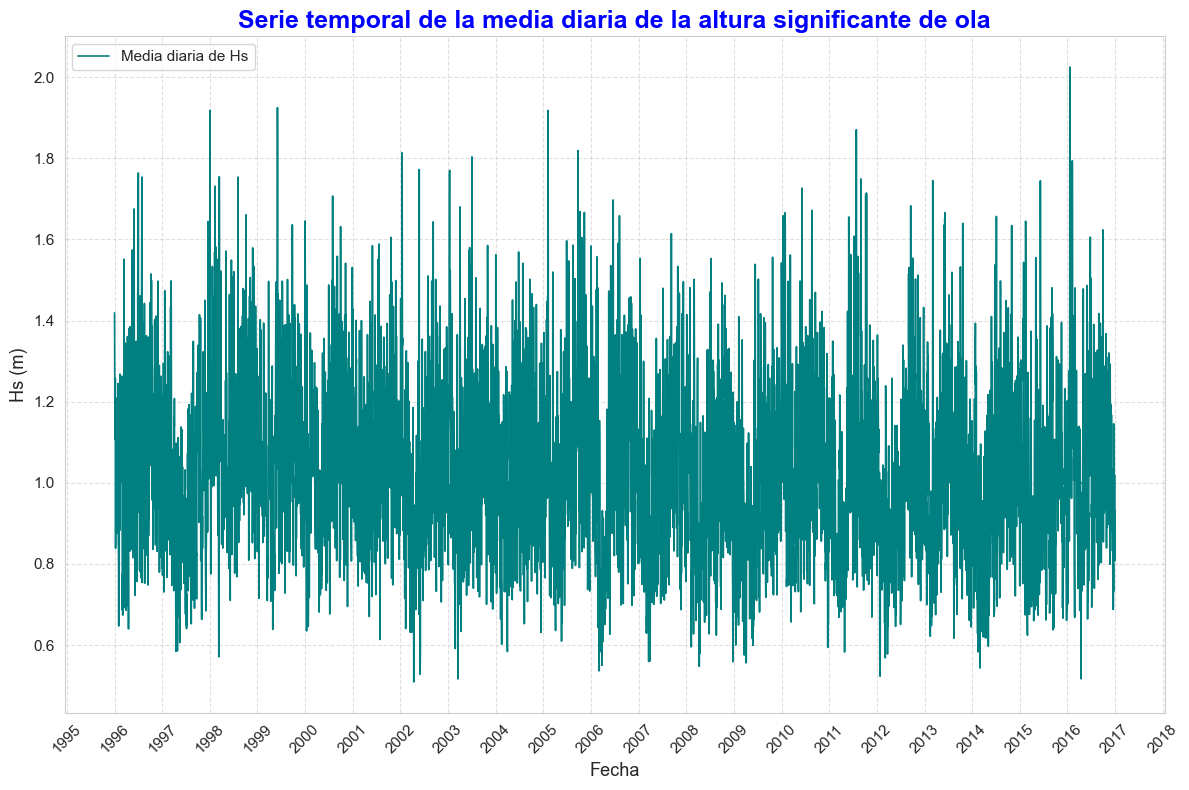

In [22]:
!pip install pymannkendall

import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np
import pymannkendall as mk
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

# nombre del archivo de Hs
archivo_csv = r"C:\Users\danna\INSTRUGEO\HSig_con_dia_del_anio.csv"

# variable global para guardar la media diaria
hs_media_diaria = None

def graficar_media_diaria_hs(archivo_csv):
    try:
        global hs_media_diaria

        # leer archivo y convertir fecha
        df = pd.read_csv(archivo_csv, parse_dates=["Date"])

        # asegurar que la columna de Hs sea numérica
        df["Hs (m)"] = pd.to_numeric(df["Hs (m)"], errors="coerce")

        # verificar que existan las columnas necesarias
        columnas_requeridas = {"Date", "DiaDelAnio", "Hs (m)"}
        if not columnas_requeridas.issubset(df.columns):
            raise ValueError(f"El archivo debe contener las columnas {columnas_requeridas}.")

        # calcular media diaria por fecha completa
        hs_media_diaria = df.groupby("Date")["Hs (m)"].mean().reset_index()

        # crear figura
        fig, ax = plt.subplots(figsize=(12, 8))
        sns.set_style("whitegrid")

        # graficar serie diaria
        ax.plot(
            hs_media_diaria["Date"],
            hs_media_diaria["Hs (m)"],
            color="teal",
            linewidth=1.2,
            label="Media diaria de Hs"
        )

        # formato del eje X para mostrar años
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        # título y etiquetas
        ax.set_title(
            "Serie temporal de la media diaria de la altura significante de ola",
            fontsize=18,
            color="blue",
            fontweight="bold"
        )
        ax.set_xlabel("Fecha", fontsize=13)
        ax.set_ylabel("Hs (m)", fontsize=13)

        # mejorar etiquetas
        ax.tick_params(axis='x', rotation=45, labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        # leyenda y grilla
        ax.legend(fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.6)

        plt.tight_layout()

        # guardar imagen antes de mostrar
        plt.savefig("Serie_media_diaria_Hs.png", dpi=300, bbox_inches="tight")

        plt.show()

    except Exception as e:
        print(f"Error: {e}")

graficar_media_diaria_hs(archivo_csv)

Ecuación de la línea de tendencia: y = -0.000009x + 1.049216


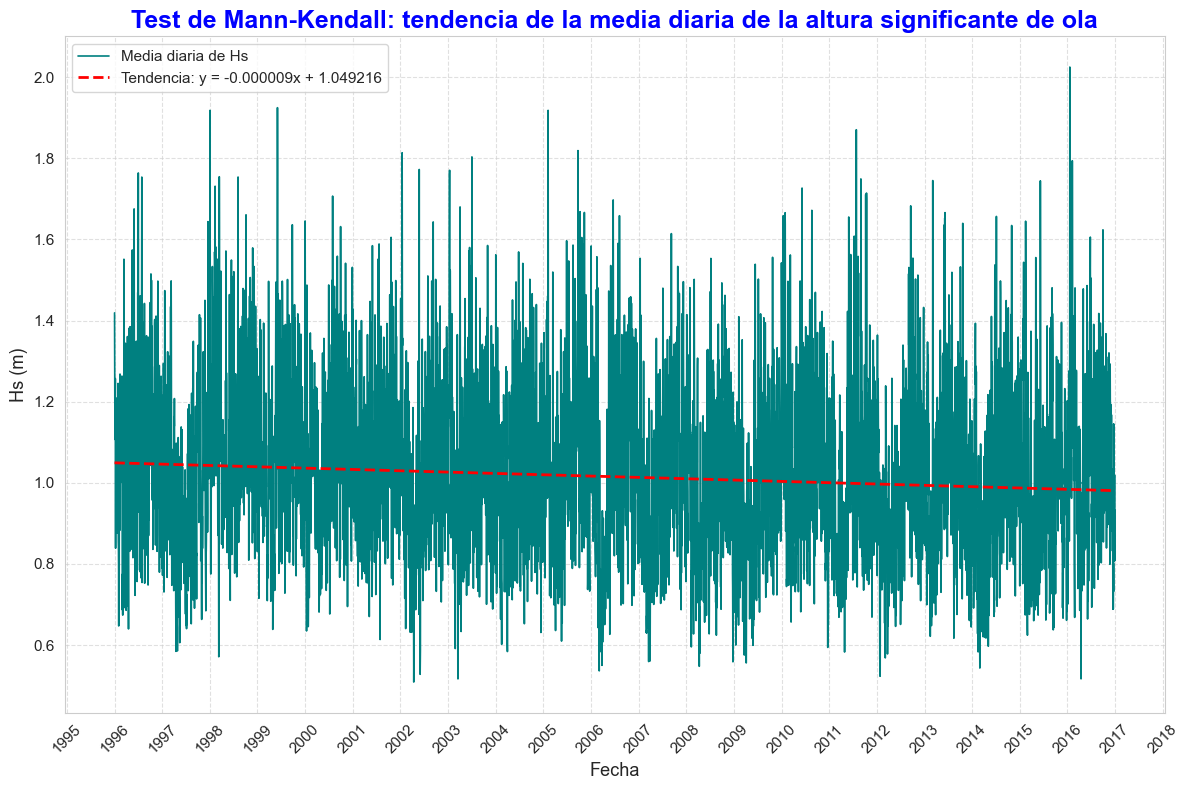

Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.0), z=np.float64(-8.293517653580018), Tau=np.float64(-0.06314236196977492), s=np.float64(-1857540.0), var_s=np.float64(50164713316.666664), slope=np.float64(-8.944739786404464e-06), intercept=np.float64(1.0492164070808614))


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import matplotlib.dates as mdates
import seaborn as sns

# asegurarse de que hs_media_diaria ya exista
data = hs_media_diaria["Hs (m)"]

# aplicar test de Mann-Kendall
res = mk.original_test(data)

# extraer pendiente e intersección
slope = res.slope
intercept = res.intercept

# construir línea de tendencia
trend_line = np.arange(len(data)) * slope + intercept

# imprimir ecuación de la recta
print(f"Ecuación de la línea de tendencia: y = {slope:.6f}x + {intercept:.6f}")

# estilo visual
sns.set_style("whitegrid")

# graficar serie y tendencia
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(
    hs_media_diaria["Date"],
    data,
    label="Media diaria de Hs",
    color="teal",
    linewidth=1.2
)

ax.plot(
    hs_media_diaria["Date"],
    trend_line,
    linestyle="dashed",
    color="red",
    linewidth=2,
    label=f"Tendencia: y = {slope:.6f}x + {intercept:.6f}"
)

# formato del eje X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# etiquetas y título
ax.set_ylabel("Hs (m)", fontsize=13)
ax.set_xlabel("Fecha", fontsize=13)
ax.set_title(
    "Test de Mann-Kendall: tendencia de la media diaria de la altura significante de ola",
    fontsize=18,
    color="blue",
    fontweight="bold"
)

# leyenda y grilla
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# guardar figura
plt.savefig("Tendencia_MannKendall_Hs.png", dpi=300, bbox_inches="tight")

plt.show()

# imprimir resultado completo del test
manni_hs = mk.original_test(hs_media_diaria["Hs (m)"], alpha=0.05)
print(manni_hs)

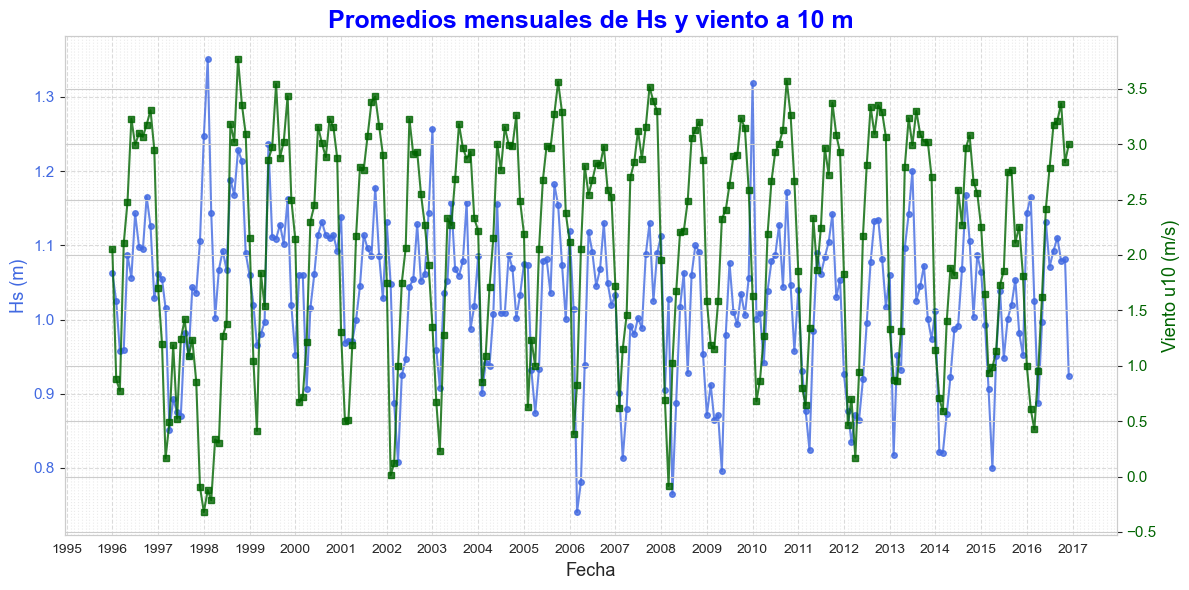

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

# estilo general
sns.set_style("whitegrid")

# Cargar los datos reales
HS = pd.read_csv(r"C:\Users\danna\INSTRUGEO\HSig_con_dia_del_anio.csv")
Viento = pd.read_csv(r"C:\Users\danna\INSTRUGEO\Viento_con_dia_del_anio.csv")

# Asegurarse de que las columnas sean numéricas
HS["Hs (m)"] = pd.to_numeric(HS["Hs (m)"], errors="coerce")
Viento["Viento_u10 (m/s)"] = pd.to_numeric(Viento["Viento_u10 (m/s)"], errors="coerce")

# Convertir la columna Date a datetime
HS["Date"] = pd.to_datetime(HS["Date"], errors="coerce")
Viento["Date"] = pd.to_datetime(Viento["Date"], errors="coerce")

# Extraer año y mes
HS["Year"] = HS["Date"].dt.year
HS["Month"] = HS["Date"].dt.month
Viento["Year"] = Viento["Date"].dt.year
Viento["Month"] = Viento["Date"].dt.month

# Calcular media mensual
HS_monthly = HS.groupby(["Year", "Month"])["Hs (m)"].mean().reset_index()
Viento_monthly = Viento.groupby(["Year", "Month"])["Viento_u10 (m/s)"].mean().reset_index()

# Crear columna fecha representando el primer día de cada mes
HS_monthly["Date"] = pd.to_datetime(dict(year=HS_monthly["Year"], month=HS_monthly["Month"], day=1))
Viento_monthly["Date"] = pd.to_datetime(dict(year=Viento_monthly["Year"], month=Viento_monthly["Month"], day=1))

# Renombrar columnas para que quede más limpio
HS_monthly.rename(columns={"Hs (m)": "Media Hs"}, inplace=True)
Viento_monthly.rename(columns={"Viento_u10 (m/s)": "Media Viento"}, inplace=True)

# Crear figura y eje principal
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje Y izquierdo - Hs
ax1.set_xlabel("Fecha", fontsize=13)
ax1.set_ylabel("Hs (m)", color="royalblue", fontsize=13)
ax1.plot(
    HS_monthly["Date"],
    HS_monthly["Media Hs"],
    marker="o",
    markersize=4,
    color="royalblue",
    label="Hs (m)",
    alpha=0.8,
    linewidth=1.5
)
ax1.tick_params(axis="y", labelcolor="royalblue", labelsize=11)

# Formato del eje X
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.MonthLocator())

# Grillas principales y secundarias
ax1.grid(True, which="major", linestyle="--", alpha=0.7)
ax1.grid(True, which="minor", linestyle=":", alpha=0.4)

# Eje Y derecho - viento
ax2 = ax1.twinx()
ax2.set_ylabel("Viento u10 (m/s)", color="darkgreen", fontsize=13)
ax2.plot(
    Viento_monthly["Date"],
    Viento_monthly["Media Viento"],
    marker="s",
    markersize=4,
    color="darkgreen",
    label="Viento u10 (m/s)",
    alpha=0.8,
    linewidth=1.5
)
ax2.tick_params(axis="y", labelcolor="darkgreen", labelsize=11)

# Título
plt.title(
    "Promedios mensuales de Hs y viento a 10 m",
    fontsize=18,
    color="blue",
    fontweight="bold"
)

# Ajustar layout
fig.tight_layout()

# Guardar figura
plt.savefig("Promedios_mensuales_Hs_Viento.png", dpi=300, bbox_inches="tight")

# Mostrar figura
plt.show()

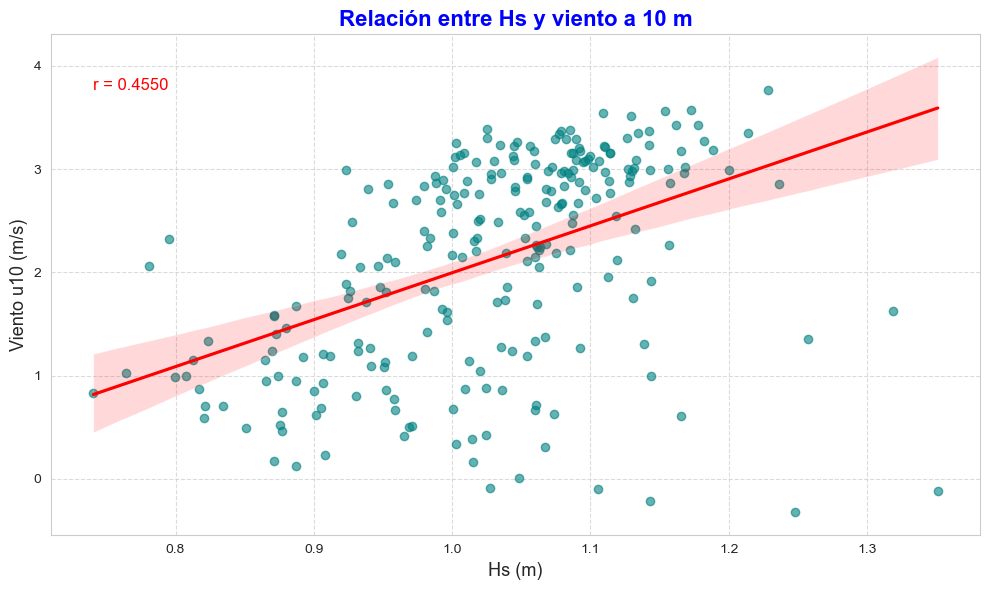

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# unir los datos mensuales de Hs y viento
merged_data = pd.merge(
    HS_monthly[['Date', 'Media Hs']],
    Viento_monthly[['Date', 'Media Viento']],
    on='Date'
)

# calcular correlación
correlation = merged_data["Media Hs"].corr(merged_data["Media Viento"])

# gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.regplot(
    data=merged_data,
    x="Media Hs",
    y="Media Viento",
    scatter_kws={'alpha': 0.6, 'color': 'teal'},
    line_kws={'color': 'red'}
)

# título
plt.title(
    "Relación entre Hs y viento a 10 m",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

plt.xlabel("Hs (m)", fontsize=13)
plt.ylabel("Viento u10 (m/s)", fontsize=13)

# texto de correlación
plt.text(
    x=merged_data["Media Hs"].min(),
    y=merged_data["Media Viento"].max(),
    s=f"r = {correlation:.4f}",
    fontsize=12,
    color="red"
)

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Relacion_Hs_Viento.png", dpi=300, bbox_inches="tight")
plt.show()

<H3>PUNTO 4

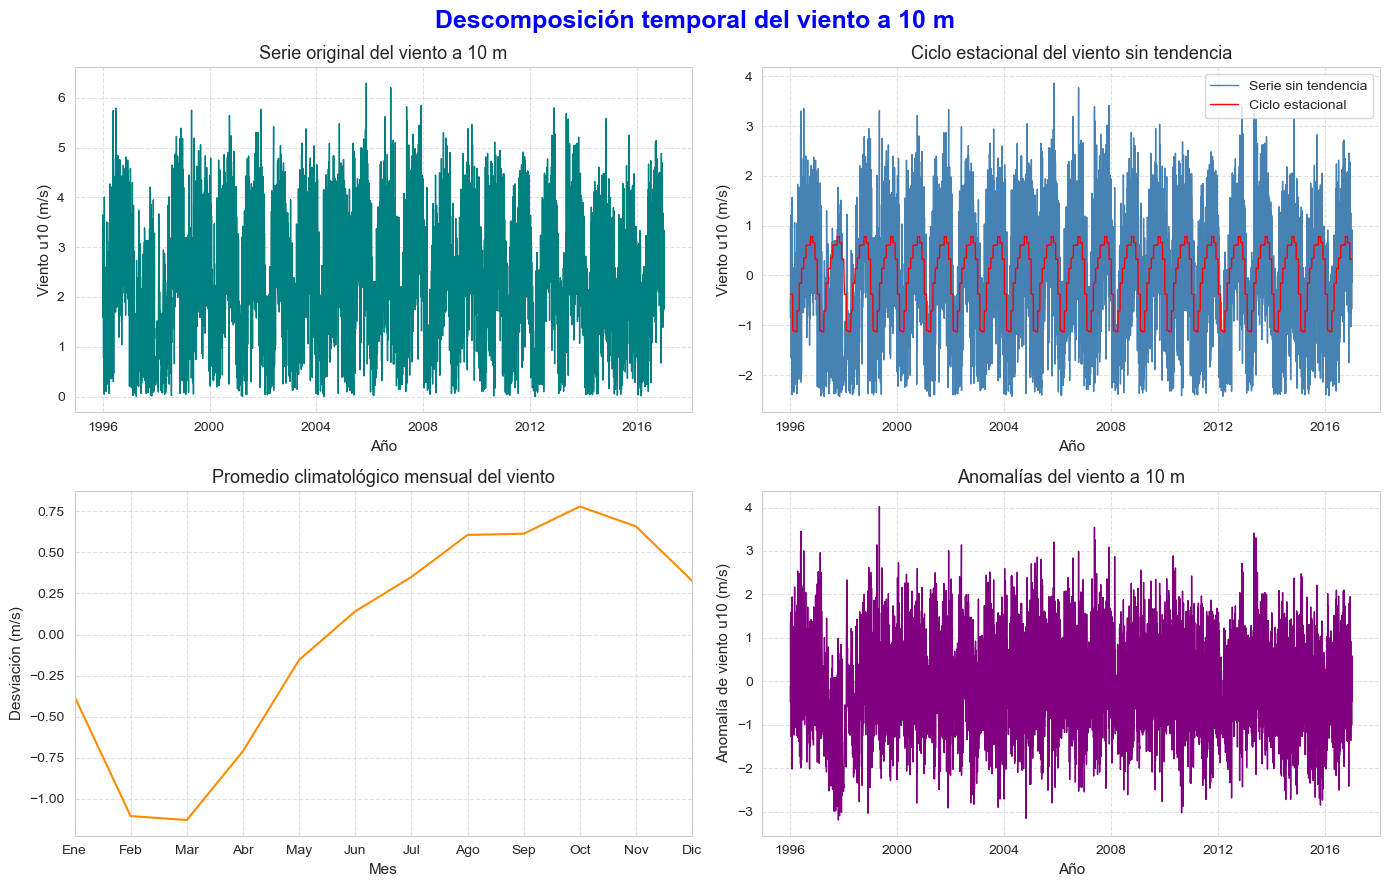

                     Anomalia_Viento_u10_ms
Fecha                                      
1996-01-01 06:00:00                1.344829
1996-01-02 06:00:00               -0.475088
1996-01-03 06:00:00               -0.106157
1996-01-04 06:00:00               -0.318918
1996-01-05 06:00:00                0.530903


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend
import seaborn as sns

# usar el dataframe que ya creaste con la media diaria del viento
# asegurarse de que Date sea datetime y ponerla como índice
viento_media_diaria["Date"] = pd.to_datetime(viento_media_diaria["Date"])
viento_media_diaria.set_index("Date", inplace=True)

# extraer la serie temporal del viento u10
viento = viento_media_diaria["Viento_u10 (m/s)"].copy()

# filtrar valores anómalos (por ejemplo, datos negativos si no quieres considerarlos)
viento[viento < 0] = np.nan

# eliminar valores faltantes
viento.dropna(inplace=True)

# serie original
YO = viento.copy()

# vector de tiempo basado en el índice de fechas
X = YO.index

# calcular climatología mensual (promedio para cada mes del año)
niveles_por_mes = YO.groupby(YO.index.month).mean()

# quitar la media total para dejar solo la señal estacional relativa
YOm = niveles_por_mes - niveles_por_mes.mean()

# reconstruir el ciclo estacional para toda la serie
YOM = YO.index.map(lambda d: YOm.loc[d.month]).values

# remover tendencia lineal de la serie original
yf = detrend(YO.values)

# calcular anomalías quitando la componente estacional
Yciclica = yf - YOM

# estilo visual
sns.set_style("whitegrid")

# crear subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Subplot 1: serie original del viento
axes[0, 0].plot(X, YO, linewidth=1, color="teal")
axes[0, 0].set_title("Serie original del viento a 10 m", fontsize=13)
axes[0, 0].set_xlabel("Año", fontsize=11)
axes[0, 0].set_ylabel("Viento u10 (m/s)", fontsize=11)
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# Subplot 2: serie sin tendencia + ciclo estacional
axes[0, 1].plot(X, yf, linewidth=1, label="Serie sin tendencia", color="steelblue")
axes[0, 1].plot(X, YOM, linewidth=1, label="Ciclo estacional", color="red")
axes[0, 1].set_title("Ciclo estacional del viento sin tendencia", fontsize=13)
axes[0, 1].set_xlabel("Año", fontsize=11)
axes[0, 1].set_ylabel("Viento u10 (m/s)", fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# Subplot 3: promedio climatológico mensual
axes[1, 0].plot(range(1, 13), YOm.values, linewidth=1.5, color="darkorange")
axes[1, 0].set_title("Promedio climatológico mensual del viento", fontsize=13)
axes[1, 0].set_xlabel("Mes", fontsize=11)
axes[1, 0].set_ylabel("Desviación (m/s)", fontsize=11)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                            'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
axes[1, 0].set_xlim([1, 12])
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# Subplot 4: anomalías
axes[1, 1].plot(X, Yciclica, linewidth=1, color="purple")
axes[1, 1].set_title("Anomalías del viento a 10 m", fontsize=13)
axes[1, 1].set_xlabel("Año", fontsize=11)
axes[1, 1].set_ylabel("Anomalía de viento u10 (m/s)", fontsize=11)
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

# título general
fig.suptitle(
    "Descomposición temporal del viento a 10 m",
    fontsize=18,
    color="blue",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("Descomposicion_anomalias_viento_u10.png", dpi=300, bbox_inches="tight")
plt.show()

# crear dataframe con anomalías
df_anomalias_viento = pd.DataFrame({
    "Fecha": X,
    "Anomalia_Viento_u10_ms": Yciclica
})

df_anomalias_viento.set_index("Fecha", inplace=True)

print(df_anomalias_viento.head())

# guardar en CSV
df_anomalias_viento.to_csv("anomalias_viento_u10.csv")


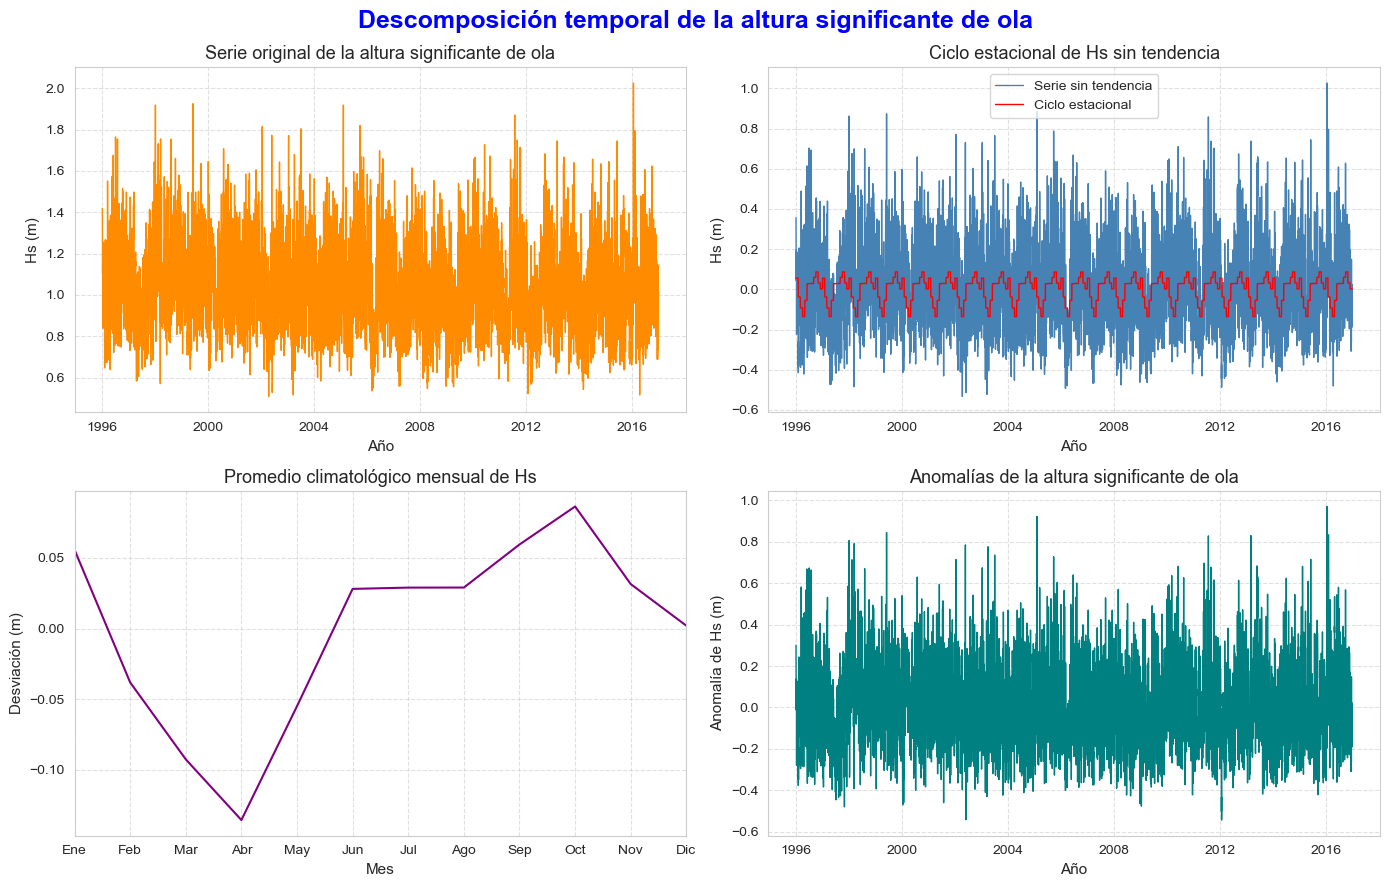

                     Anomalia_Hs_m
Fecha                             
1996-01-01 06:00:00       0.300643
1996-01-02 06:00:00       0.206799
1996-01-03 06:00:00       0.073646
1996-01-04 06:00:00      -0.011299
1996-01-05 06:00:00       0.054065


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend
import seaborn as sns

# usar el dataframe que ya creaste con la media diaria de Hs
# asegurarse de que Date sea datetime y ponerla como índice
hs_media_diaria["Date"] = pd.to_datetime(hs_media_diaria["Date"])
hs_media_diaria.set_index("Date", inplace=True)

# extraer la serie temporal de la altura significante de ola
hs = hs_media_diaria["Hs (m)"].copy()

# filtrar valores anómalos (evitar valores negativos)
hs[hs < 0] = np.nan

# eliminar valores faltantes
hs.dropna(inplace=True)

# serie original
YO = hs.copy()

# vector de tiempo basado en el índice de fechas
X = YO.index

# calcular climatología mensual (promedio para cada mes del año)
niveles_por_mes = YO.groupby(YO.index.month).mean()

# quitar la media total para dejar solo la señal estacional relativa
YOm = niveles_por_mes - niveles_por_mes.mean()

# reconstruir el ciclo estacional para toda la serie
YOM = YO.index.map(lambda d: YOm.loc[d.month]).values

# remover tendencia lineal de la serie original
yf = detrend(YO.values)

# calcular anomalías quitando la componente estacional
Yciclica = yf - YOM

# estilo visual
sns.set_style("whitegrid")

# crear subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Subplot 1: serie original de Hs
axes[0, 0].plot(X, YO, linewidth=1, color="darkorange")
axes[0, 0].set_title("Serie original de la altura significante de ola", fontsize=13)
axes[0, 0].set_xlabel("Año", fontsize=11)
axes[0, 0].set_ylabel("Hs (m)", fontsize=11)
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# Subplot 2: serie sin tendencia + ciclo estacional
axes[0, 1].plot(X, yf, linewidth=1, label="Serie sin tendencia", color="steelblue")
axes[0, 1].plot(X, YOM, linewidth=1, label="Ciclo estacional", color="red")
axes[0, 1].set_title("Ciclo estacional de Hs sin tendencia", fontsize=13)
axes[0, 1].set_xlabel("Año", fontsize=11)
axes[0, 1].set_ylabel("Hs (m)", fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# Subplot 3: promedio climatológico mensual
axes[1, 0].plot(range(1, 13), YOm.values, linewidth=1.5, color="purple")
axes[1, 0].set_title("Promedio climatológico mensual de Hs", fontsize=13)
axes[1, 0].set_xlabel("Mes", fontsize=11)
axes[1, 0].set_ylabel("Desviación (m)", fontsize=11)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                            'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
axes[1, 0].set_xlim([1, 12])
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# Subplot 4: anomalías de Hs
axes[1, 1].plot(X, Yciclica, linewidth=1, color="teal")
axes[1, 1].set_title("Anomalías de la altura significante de ola", fontsize=13)
axes[1, 1].set_xlabel("Año", fontsize=11)
axes[1, 1].set_ylabel("Anomalía de Hs (m)", fontsize=11)
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

# título general
fig.suptitle(
    "Descomposición temporal de la altura significante de ola",
    fontsize=18,
    color="blue",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("Descomposicion_anomalias_Hs.png", dpi=300, bbox_inches="tight")
plt.show()

# crear un nuevo DataFrame con las anomalías y la fecha
df_anomalias_hs = pd.DataFrame({
    "Fecha": X,
    "Anomalia_Hs_m": Yciclica
})

df_anomalias_hs.set_index("Fecha", inplace=True)

print(df_anomalias_hs.head())

# guardar en CSV
df_anomalias_hs.to_csv("anomalias_Hs.csv")


<h1>PARTE 3

In [33]:
# TRANSFORMADA DE FOURIER PARA MEDIAS MENSUALES

import pandas as pd

# Cargar los datos reales
HS = pd.read_csv(r"C:\Users\danna\INSTRUGEO\HSig_con_dia_del_anio.csv")
Viento = pd.read_csv(r"C:\Users\danna\INSTRUGEO\Viento_con_dia_del_anio.csv")

# Asegurar que las columnas sean numéricas
HS["Hs (m)"] = pd.to_numeric(HS["Hs (m)"], errors="coerce")
Viento["Viento_u10 (m/s)"] = pd.to_numeric(Viento["Viento_u10 (m/s)"], errors="coerce")

# Convertir fecha
HS["Date"] = pd.to_datetime(HS["Date"], errors="coerce")
Viento["Date"] = pd.to_datetime(Viento["Date"], errors="coerce")

# Extraer año y mes
HS["Year"] = HS["Date"].dt.year
HS["Month"] = HS["Date"].dt.month
Viento["Year"] = Viento["Date"].dt.year
Viento["Month"] = Viento["Date"].dt.month

# Calcular medias mensuales
HS_monthly = HS.groupby(["Year", "Month"])["Hs (m)"].mean().reset_index()
HS_monthly.rename(columns={"Hs (m)": "Media Hs"}, inplace=True)

Viento_monthly = Viento.groupby(["Year", "Month"])["Viento_u10 (m/s)"].mean().reset_index()
Viento_monthly.rename(columns={"Viento_u10 (m/s)": "Media Viento"}, inplace=True)

# Crear columna de tiempo continuo (clave para FFT)
HS_monthly["Date"] = pd.to_datetime(dict(year=HS_monthly["Year"], month=HS_monthly["Month"], day=1))
Viento_monthly["Date"] = pd.to_datetime(dict(year=Viento_monthly["Year"], month=Viento_monthly["Month"], day=1))

# Ordenar por fecha (MUY IMPORTANTE para FFT)
HS_monthly = HS_monthly.sort_values("Date").reset_index(drop=True)
Viento_monthly = Viento_monthly.sort_values("Date").reset_index(drop=True)

# Verificar
print(HS_monthly.head())
print(Viento_monthly.head())

   Year  Month  Media Hs       Date
0  1996      1  1.062875 1996-01-01
1  1996      2  1.024623 1996-02-01
2  1996      3  0.957906 1996-03-01
3  1996      4  0.958980 1996-04-01
4  1996      5  1.086899 1996-05-01
   Year  Month  Media Viento       Date
0  1996      1      2.052079 1996-01-01
1  1996      2      0.876800 1996-02-01
2  1996      3      0.774351 1996-03-01
3  1996      4      2.104273 1996-04-01
4  1996      5      2.478237 1996-05-01


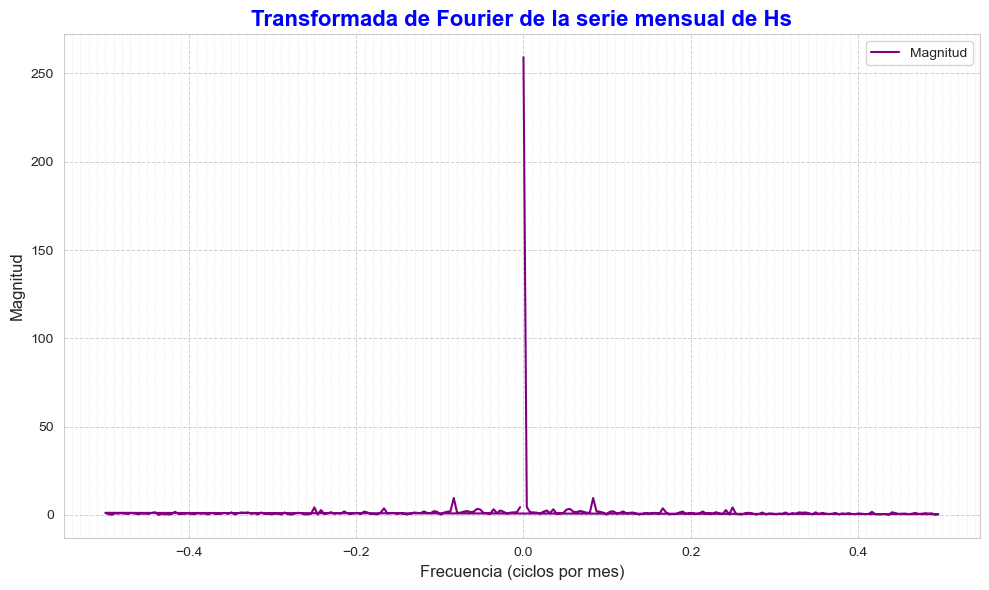

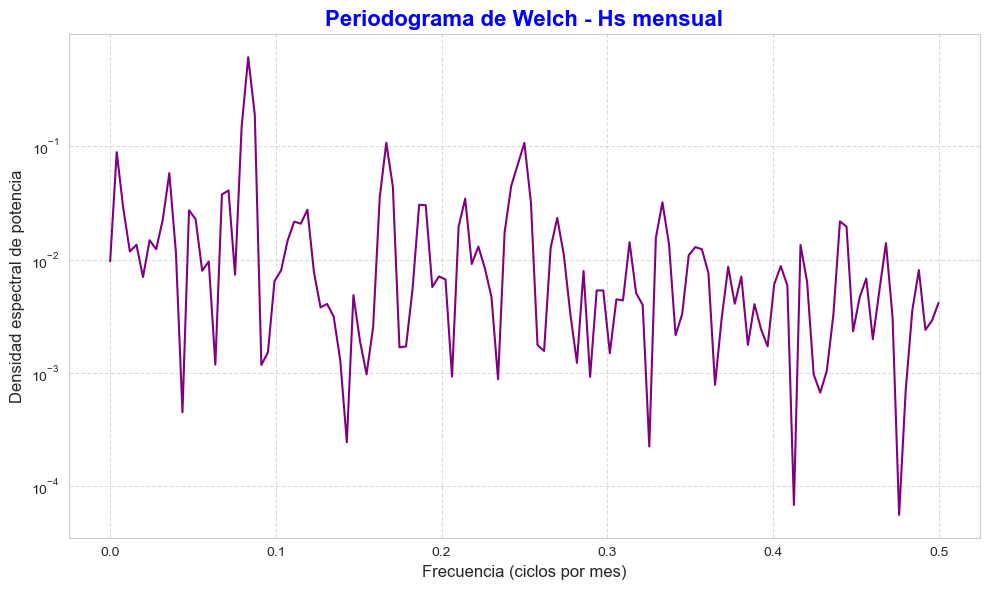

In [40]:
# FOURIER Y WELCH PARA Hs MENSUAL

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from matplotlib.ticker import MultipleLocator

# Serie mensual de Hs
hs_series = HS_monthly['Media Hs'].values

# Número de datos
n = len(hs_series)

# Intervalo de muestreo: 1 mes
dt = 1

# =========================
# TRANSFORMADA DE FOURIER
# =========================
hs_fft = fft(hs_series)
frecuencias = fftfreq(n, d=dt)

plt.figure(figsize=(10, 6))
plt.title(
    "Transformada de Fourier de la serie mensual de Hs",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

# Graficar magnitud de la FFT
plt.plot(frecuencias, np.abs(hs_fft), label="Magnitud", color="purple")

# Líneas secundarias en el eje x
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.01))
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)

# Etiquetas
plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Magnitud", fontsize=12)

# Grilla principal
plt.grid(which='major', linestyle='--', linewidth=0.7, alpha=0.9)

plt.legend()
plt.tight_layout()
plt.savefig("FFT_Hs_mensual.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# PERIODOGRAMA DE WELCH
# =========================
frecuencias_welch, psd = welch(hs_series, fs=1, nperseg=min(256, len(hs_series)))

plt.figure(figsize=(10, 6))
plt.semilogy(frecuencias_welch, psd, color="purple")

plt.title(
    "Periodograma de Welch - Hs mensual",
    fontsize=16,
    color="blue",
    fontweight="bold"
)
plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Densidad espectral de potencia", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Welch_Hs_mensual.png", dpi=300, bbox_inches="tight")
plt.show()

In [94]:
SWH_monthly

,year,month,Media SWH
0,1980,1,2.083175
1,1980,2,2.120090
2,1980,3,2.466546
3,1980,4,1.553388
4,1980,5,1.035115
...,...,...,...
235,1999,8,1.083931
236,1999,9,0.681297
237,1999,10,0.687738
238,1999,11,1.152356


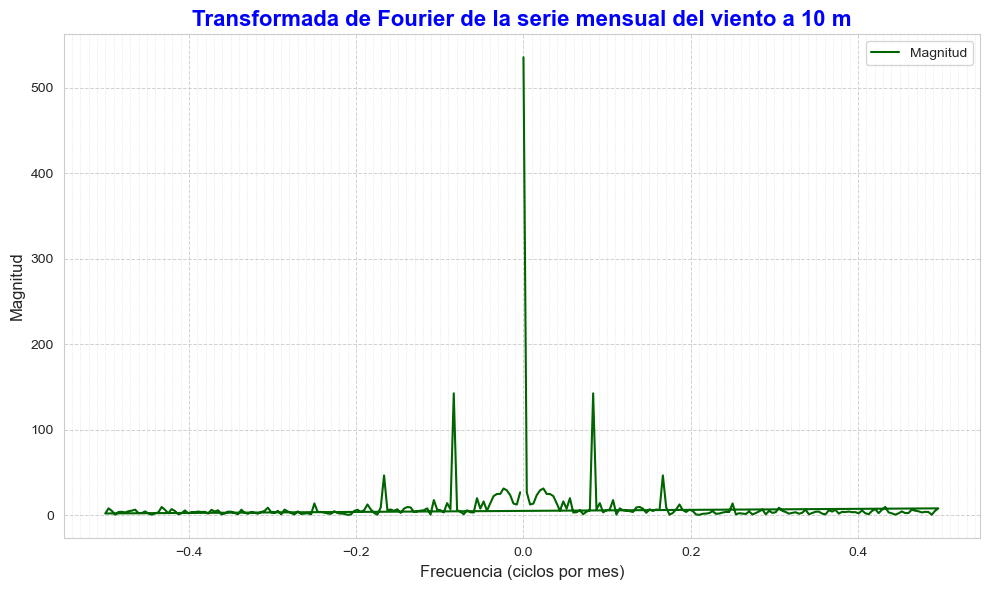

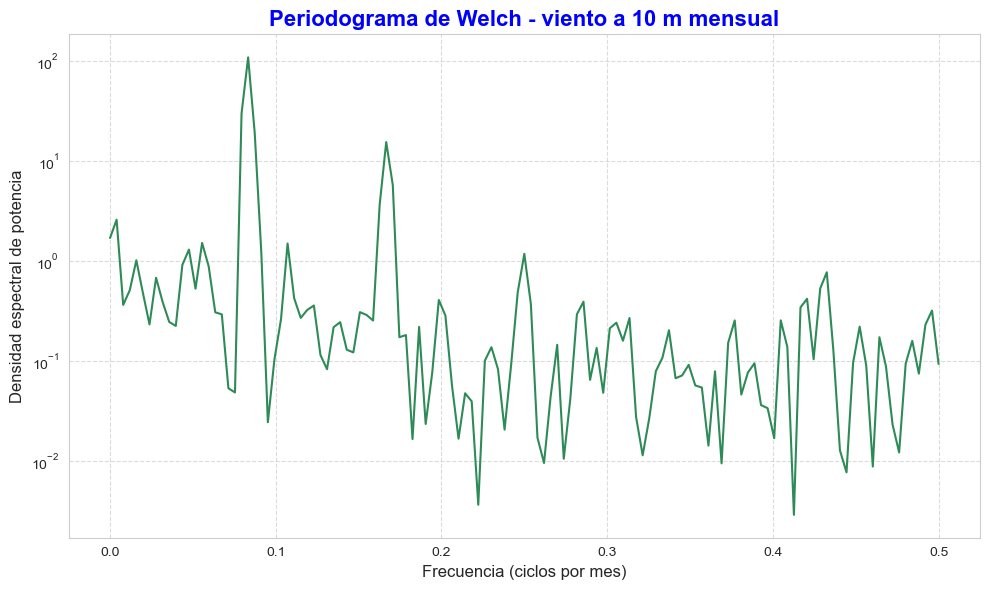

In [35]:
# FOURIER Y WELCH PARA VIENTO U10 MENSUAL

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from matplotlib.ticker import MultipleLocator

# Serie mensual del viento u10
viento_series = Viento_monthly['Media Viento'].values

# Número de datos
n = len(viento_series)

# Intervalo de muestreo: 1 mes
dt = 1

# =========================
# TRANSFORMADA DE FOURIER
# =========================
viento_fft = fft(viento_series)
frecuencias = fftfreq(n, d=dt)

plt.figure(figsize=(10, 6))
plt.title(
    "Transformada de Fourier de la serie mensual del viento a 10 m",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

# Graficar magnitud de la FFT
plt.plot(frecuencias, np.abs(viento_fft), label="Magnitud", color="darkgreen")

# Líneas secundarias en el eje x
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.01))
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)

# Etiquetas
plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Magnitud", fontsize=12)

# Grilla principal
plt.grid(which='major', linestyle='--', linewidth=0.7, alpha=0.9)

plt.legend()
plt.tight_layout()
plt.savefig("FFT_Viento_mensual.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# PERIODOGRAMA DE WELCH
# =========================
frecuencias_welch, psd = welch(viento_series, fs=1, nperseg=min(256, len(viento_series)))

plt.figure(figsize=(10, 6))
plt.semilogy(frecuencias_welch, psd, color="seagreen")

plt.title(
    "Periodograma de Welch - viento a 10 m mensual",
    fontsize=16,
    color="blue",
    fontweight="bold"
)
plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Densidad espectral de potencia", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Welch_Viento_mensual.png", dpi=300, bbox_inches="tight")
plt.show()

<h3> 3.2 serie de anomalias

In [36]:
import pandas as pd

# =========================
# ANOMALÍAS MENSUALES DE Hs
# =========================
df_anomalias_hs = pd.read_csv("anomalias_Hs.csv")
df_anomalias_hs["Fecha"] = pd.to_datetime(df_anomalias_hs["Fecha"], errors="coerce")

# crear columnas auxiliares
df_anomalias_hs["Mes"] = df_anomalias_hs["Fecha"].dt.month
df_anomalias_hs["Año"] = df_anomalias_hs["Fecha"].dt.year

# agrupar por año y mes para calcular la media mensual de la anomalía
df_anomalias_hs_mensual = df_anomalias_hs.groupby(["Año", "Mes"])["Anomalia_Hs_m"].mean().reset_index()

# ================================
# ANOMALÍAS MENSUALES DE VIENTO U10
# ================================
df_anomalias_viento = pd.read_csv("anomalias_viento_u10.csv")
df_anomalias_viento["Fecha"] = pd.to_datetime(df_anomalias_viento["Fecha"], errors="coerce")

# crear columnas auxiliares
df_anomalias_viento["Mes"] = df_anomalias_viento["Fecha"].dt.month
df_anomalias_viento["Año"] = df_anomalias_viento["Fecha"].dt.year

# agrupar por año y mes para calcular la media mensual de la anomalía
df_anomalias_viento_mensual = df_anomalias_viento.groupby(["Año", "Mes"])["Anomalia_Viento_u10_ms"].mean().reset_index()

# =========================
# VERIFICACIÓN
# =========================
print(df_anomalias_hs.head())
print(df_anomalias_viento.head())

print(df_anomalias_hs_mensual.head())
print(df_anomalias_viento_mensual.head())

                Fecha  Anomalia_Hs_m  Mes   Año
0 1996-01-01 06:00:00       0.300643    1  1996
1 1996-01-02 06:00:00       0.206799    1  1996
2 1996-01-03 06:00:00       0.073646    1  1996
3 1996-01-04 06:00:00      -0.011299    1  1996
4 1996-01-05 06:00:00       0.054065    1  1996
                Fecha  Anomalia_Viento_u10_ms  Mes   Año
0 1996-01-01 06:00:00                1.344829    1  1996
1 1996-01-02 06:00:00               -0.475088    1  1996
2 1996-01-03 06:00:00               -0.106157    1  1996
3 1996-01-04 06:00:00               -0.318918    1  1996
4 1996-01-05 06:00:00                0.530903    1  1996
    Año  Mes  Anomalia_Hs_m
0  1996    1      -0.055282
1  1996    2       0.000681
2  1996    3      -0.011250
3  1996    4       0.033118
4  1996    5       0.080606
    Año  Mes  Anomalia_Viento_u10_ms
0  1996    1                0.090565
1  1996    2                0.012109
2  1996    3                0.140544
3  1996    4                0.452433
4  1996    5     

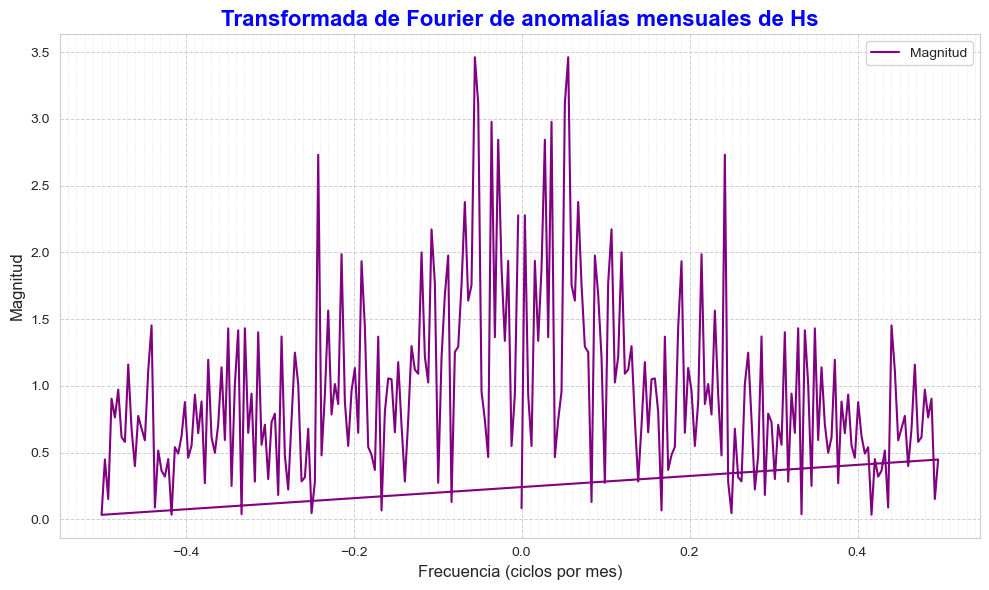

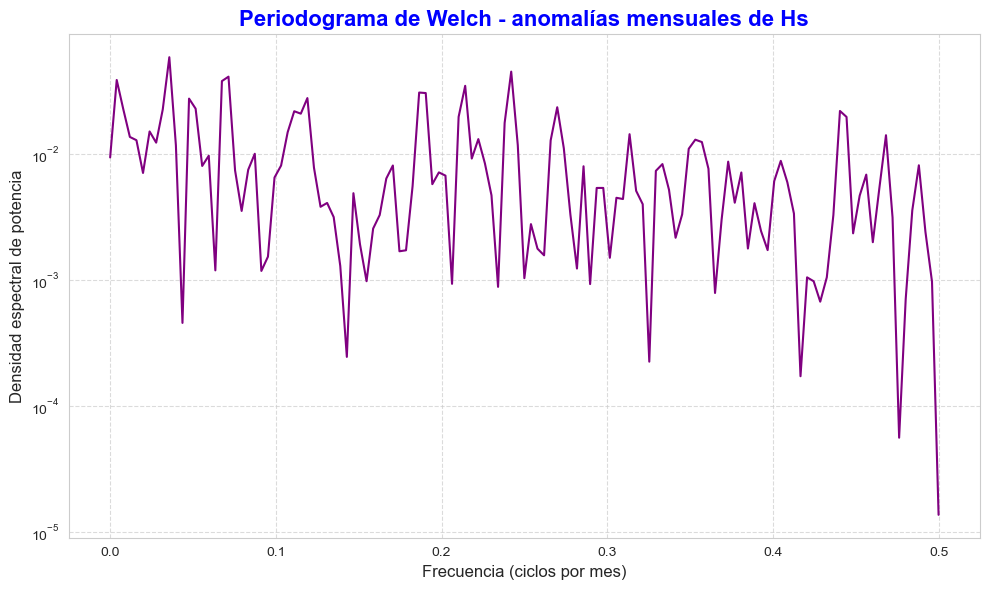

In [39]:
# FOURIER Y WELCH PARA ANOMALÍAS DE Hs

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from matplotlib.ticker import MultipleLocator

# Serie mensual de anomalías de Hs
hs_anom_series = df_anomalias_hs_mensual['Anomalia_Hs_m'].values

# Número de datos
n = len(hs_anom_series)

# Intervalo de muestreo (mensual)
dt = 1

# =========================
# TRANSFORMADA DE FOURIER
# =========================
hs_fft = fft(hs_anom_series)
frecuencias = fftfreq(n, d=dt)

plt.figure(figsize=(10, 6))
plt.title(
    "Transformada de Fourier de anomalías mensuales de Hs",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

plt.plot(frecuencias, np.abs(hs_fft), label="Magnitud", color="purple")

# Líneas secundarias
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.01))
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)

# Etiquetas
plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Magnitud", fontsize=12)

# Grilla principal
plt.grid(which='major', linestyle='--', linewidth=0.7, alpha=0.9)

plt.legend()
plt.tight_layout()
plt.savefig("FFT_anomalias_Hs.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# PERIODOGRAMA DE WELCH
# =========================
frecuencias_welch, psd = welch(
    hs_anom_series,
    fs=1,
    nperseg=min(256, len(hs_anom_series))
)

plt.figure(figsize=(10, 6))
plt.semilogy(frecuencias_welch, psd, color="purple")

plt.title(
    "Periodograma de Welch - anomalías mensuales de Hs",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Densidad espectral de potencia", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Welch_anomalias_Hs.png", dpi=300, bbox_inches="tight")
plt.show()

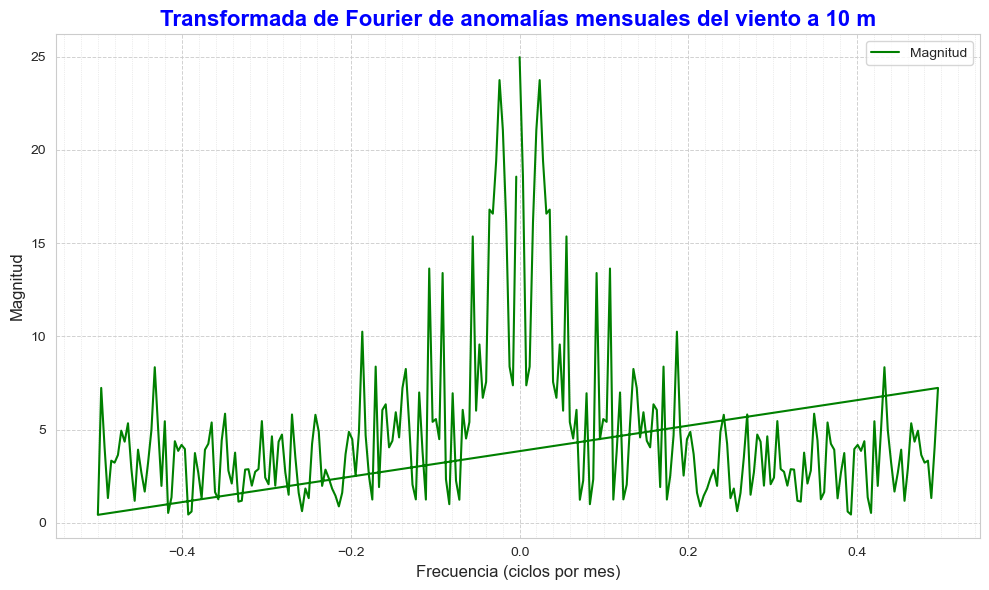

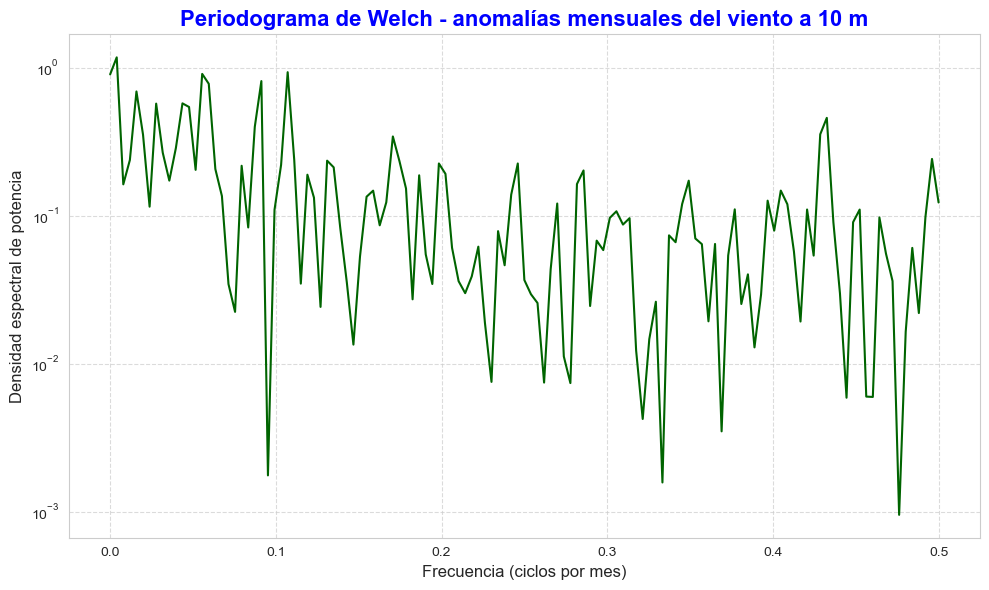

In [38]:
# FOURIER Y WELCH PARA ANOMALÍAS DE VIENTO U10

import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.signal import welch

# Serie de tiempo del viento (anomalías mensuales)
vcl_series = df_anomalias_viento_mensual['Anomalia_Viento_u10_ms'].values

# Número de datos
n = len(vcl_series)

# Intervalo de muestreo (mensual)
dt = 1

# =========================
# TRANSFORMADA DE FOURIER
# =========================
vcl_fft = fft(vcl_series)
frecuencias = fftfreq(n, d=dt)

plt.figure(figsize=(10, 6))
plt.title(
    "Transformada de Fourier de anomalías mensuales del viento a 10 m",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

# (SE DEJA LA LÍNEA CONTINUA COMO PEDISTE)
plt.plot(frecuencias, np.abs(vcl_fft), label="Magnitud", color="green")

# líneas secundarias (sin exagerar)
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.02))
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.7)

# etiquetas
plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Magnitud", fontsize=12)

# grilla principal
plt.grid(which='major', linestyle='--', linewidth=0.7, alpha=0.9)

plt.legend()
plt.tight_layout()
plt.savefig("FFT_anomalias_viento.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# PERIODOGRAMA DE WELCH
# =========================
frecuencias, psd = welch(
    vcl_series,
    fs=1,
    nperseg=min(256, len(vcl_series))
)

plt.figure(figsize=(10, 6))
plt.semilogy(frecuencias, psd, color="darkgreen")

plt.title(
    "Periodograma de Welch - anomalías mensuales del viento a 10 m",
    fontsize=16,
    color="blue",
    fontweight="bold"
)

plt.xlabel("Frecuencia (ciclos por mes)", fontsize=12)
plt.ylabel("Densidad espectral de potencia", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Welch_anomalias_viento.png", dpi=300, bbox_inches="tight")
plt.show()

<h3>3.3 banda pasa ENSO

In [41]:
# =========================
# MEDIA DIARIA DE Hs
# =========================
import pandas as pd

hs_media_diaria = pd.read_csv(r"C:\Users\danna\INSTRUGEO\HSig_con_dia_del_anio.csv", parse_dates=["Date"])
hs_media_diaria["Hs (m)"] = pd.to_numeric(hs_media_diaria["Hs (m)"], errors="coerce")

# dejar solo fecha sin hora
hs_media_diaria["Date"] = hs_media_diaria["Date"].dt.strftime("%Y-%m-%d")

# agrupar por fecha y calcular media diaria
hs_media_diaria = hs_media_diaria.groupby(["Date"])["Hs (m)"].mean().reset_index()

# mostrar nombres de columnas
hs_media_diaria.columns

Index(['Date', 'Hs (m)'], dtype='object')

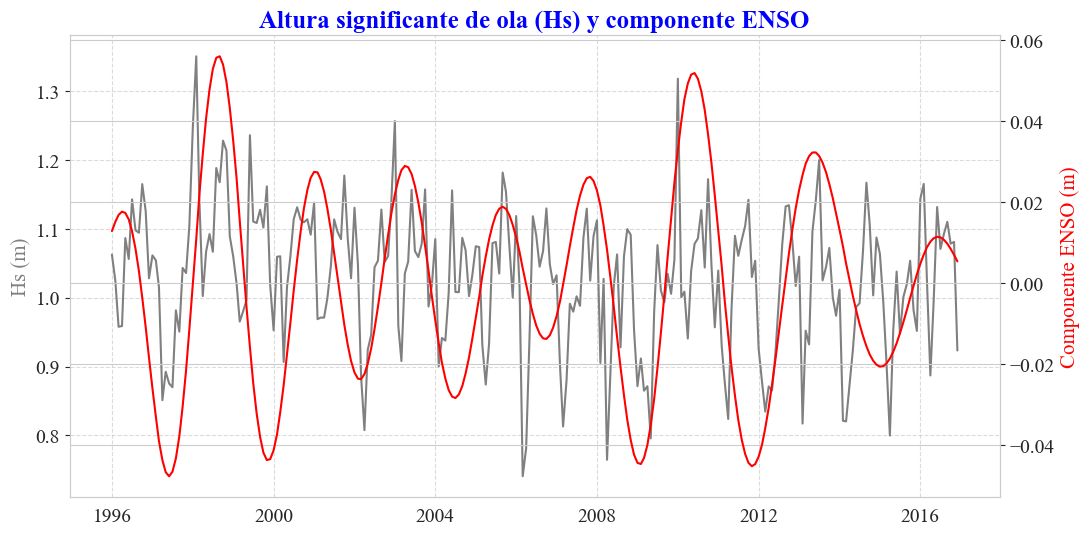

In [43]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# serie original
ax1.plot(time, hs_values, color='gray', label='Serie original')
ax1.set_ylabel("Hs (m)", color='gray')

# eje secundario
ax2 = ax1.twinx()
ax2.plot(time, serie_filtrada, 'r', label='ENSO (2–4 años)')
ax2.set_ylabel("Componente ENSO (m)", color='red')

# título
plt.title(
    "Altura significante de ola (Hs) y componente ENSO",
    fontsize=18,
    color="blue",
    fontweight="bold"
)

ax1.grid(True, linestyle="--", alpha=0.7)
plt.show()